# 1. KNN, Naive Bayes Classification &nbsp;|&nbsp; 2. K-Means / K-Medoid / K-Means++ Clustering

This notebook follows the exact task order given in the assignment:

**1. KNN, Naive Bayes Classification**
- FOR KNN
  1. Take dataset with 4 parameters and perform: a) Euclidean distance, b) Manhattan distance, c) Minkowski distance
  2. Find train accuracy and test accuracy
  3. Find optimal K value using test accuracy and rebuild
  4. Apply for both classification and regression
  5. Naive Bayes Classification (comparison)

**2. K-Means / K-Medoid / K-Means++ Clustering**
- a) Perform K-Means for sample data points using: Euclidean, Manhattan, Squared Euclidean, Cosine distance measures
- b) K-Means++ initialization
- c) K-Medoid (PAM) clustering
- d) Apply K-Means for applications: i) Image Compression, ii) Identify players that are similar to each other
- e) Evaluate the method using: i) Silhouette Coefficient, ii) Sum of Squared Errors
- f) Find the optimal K number of clusters using the elbow method

All datasets used are **synthetically generated inside this notebook** (fully reproducible, `random_state=42`) and are also exported as standalone `.csv` files alongside this notebook.


In [1]:
# ---- Core imports ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_regression, make_blobs, load_sample_image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              mean_squared_error, r2_score, silhouette_score)
from sklearn.cluster import KMeans

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True
print("Libraries loaded.")


Libraries loaded.


---
# 1. KNN, Naive Bayes Classification

## FOR KNN

### How KNN works (from the notes)
1. Similarity is measured between the **test point** and every **training point**.
2. It is a **non-parametric**, **instance-based** ("lazy") learner — it just stores the training data, there is no explicit training phase.
3. **Algorithm:**
   1. Choose `K` = number of nearest neighbors.
   2. Compute the distance from the test sample to every training sample.
   3. Sort the distances (shortest distance → rank 1).
   4. Take the classes/values of the `K` nearest neighbors.
   5. **Classification:** majority class wins. **Regression:** average the `K` neighbors' target values.


### 1. Take dataset with 4 parameters and perform

First, the dataset. We create a synthetic **product-quality dataset** in the same spirit as the notes' *Acid Durability / Strength → Good/Bad* example, but extended to **4 parameters**: `Acid_Durability`, `Strength`, `Thickness`, `Elasticity`, predicting `Class` (`Good` / `Bad`).


In [2]:
X, y = make_classification(
    n_samples=300, n_features=4, n_informative=4, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.6, flip_y=0.03, random_state=42
)

feature_names = ['Acid_Durability', 'Strength', 'Thickness', 'Elasticity']
df_clf = pd.DataFrame(X, columns=feature_names)
# rescale every feature to a friendly 0-10 range (like the handwritten example)
df_clf = (df_clf - df_clf.min()) / (df_clf.max() - df_clf.min()) * 10
df_clf['Class'] = np.where(y == 1, 'Good', 'Bad')

df_clf.to_csv('classification_dataset.csv', index=False)
print(df_clf.shape)
df_clf.head()


(300, 5)


,Acid_Durability,Strength,Thickness,Elasticity,Class
0,3.567586,3.645133,7.992391,5.118040,Good
1,4.610234,4.099716,5.950285,5.424585,Bad
2,2.559293,6.678213,4.721113,4.979517,Bad
3,6.145561,2.180274,4.420227,4.421951,Bad
4,6.704908,7.404581,7.244211,0.000000,Good


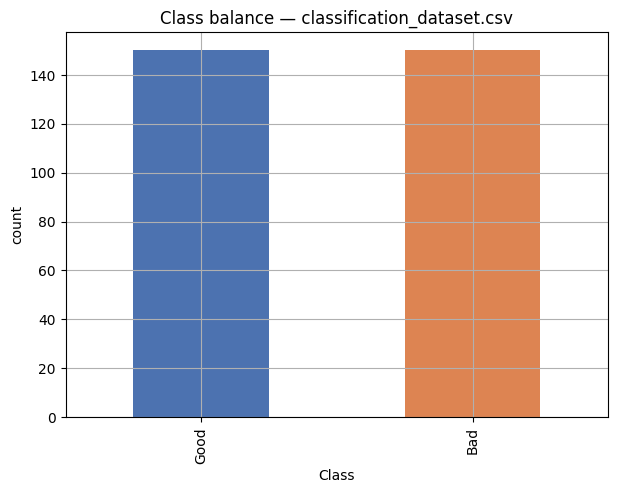

In [3]:
df_clf['Class'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Class balance — classification_dataset.csv')
plt.ylabel('count')
plt.show()


#### a) Euclidean distance &nbsp; b) Manhattan distance &nbsp; c) Minkowski distance

$$\text{a) Euclidean: } d(x,y) = \sqrt{\sum_i (x_i-y_i)^2} \qquad\qquad \text{b) Manhattan: } d(x,y) = \sum_i |x_i-y_i|$$

$$\text{c) Minkowski (order }p\text{): } d(x,y) = \left(\sum_i |x_i-y_i|^p\right)^{1/p}$$

Minkowski is the **general form**: `p=1` gives Manhattan, `p=2` gives Euclidean.


In [4]:
def euclidean_distance(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    return np.sqrt(np.sum((a - b) ** 2))

def manhattan_distance(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    return np.sum(np.abs(a - b))

def minkowski_distance(a, b, p=3):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    return np.sum(np.abs(a - b) ** p) ** (1 / p)

# Demo on the first two rows of the dataset
p1 = df_clf.loc[0, feature_names].values
p2 = df_clf.loc[1, feature_names].values

print(f"Point A: {p1}")
print(f"Point B: {p2}")
print(f"Euclidean distance      : {euclidean_distance(p1, p2):.4f}")
print(f"Manhattan distance      : {manhattan_distance(p1, p2):.4f}")
print(f"Minkowski (p=3) distance: {minkowski_distance(p1, p2, p=3):.4f}")


Point A: [3.56758585 3.64513328 7.99239098 5.11803969]
Point B: [4.61023429 4.09971648 5.95028506 5.42458467]
Euclidean distance      : 2.3575
Manhattan distance      : 3.8459
Minkowski (p=3) distance: 2.1380


### 2) Find train accuracy and test accuracy

First we split the data into train/test sets and scale the features.


In [5]:
X = df_clf[feature_names].values
y = (df_clf['Class'] == 'Good').astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]}   Test size: {X_test.shape[0]}")


Train size: 210   Test size: 90


Now, our own KNN classifier, from scratch — following the algorithm exactly: compute distances → sort → take K nearest → majority vote. It accepts any of the 3 distance functions above (a, b, c), and we compute **train accuracy and test accuracy** for each.


In [6]:
class KNNClassifierScratch:
    def __init__(self, k=5, distance_fn=euclidean_distance):
        self.k = k
        self.distance_fn = distance_fn

    def fit(self, X, y):
        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y)
        return self

    def _predict_one(self, x):
        dists = np.array([self.distance_fn(x, xt) for xt in self.X_train])
        nearest_idx = np.argsort(dists)[:self.k]          # step 3: sort, rank
        nearest_labels = self.y_train[nearest_idx]          # step 4: gather classes
        values, counts = np.unique(nearest_labels, return_counts=True)
        return values[np.argmax(counts)]                    # step 5: majority vote

    def predict(self, X):
        return np.array([self._predict_one(x) for x in np.asarray(X)])

# Evaluate k=5 with each distance metric
results = []
for name, fn in [('Euclidean', euclidean_distance),
                  ('Manhattan', manhattan_distance),
                  ('Minkowski (p=3)', lambda a, b: minkowski_distance(a, b, p=3))]:
    model = KNNClassifierScratch(k=5, distance_fn=fn).fit(X_train_s, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train_s))
    test_acc = accuracy_score(y_test, model.predict(X_test_s))
    results.append([name, train_acc, test_acc])

distance_comparison = pd.DataFrame(results, columns=['Distance metric', 'Train accuracy', 'Test accuracy'])
distance_comparison


,Distance metric,Train accuracy,Test accuracy
0,Euclidean,0.976190,0.955556
1,Manhattan,0.971429,0.955556
2,Minkowski (p=3),0.980952,0.955556


### 3) Find optimal K value using test accuracy and rebuild

We sweep `K` from 1 to 30, track **train** and **test** accuracy at every K, and pick the `K` that maximizes **test** accuracy (this avoids the overfitting we'd get by only looking at train accuracy, which is highest at K=1). Then we rebuild the model using that optimal K.


Optimal K (best test accuracy) = 3  ->  test accuracy = 0.9556


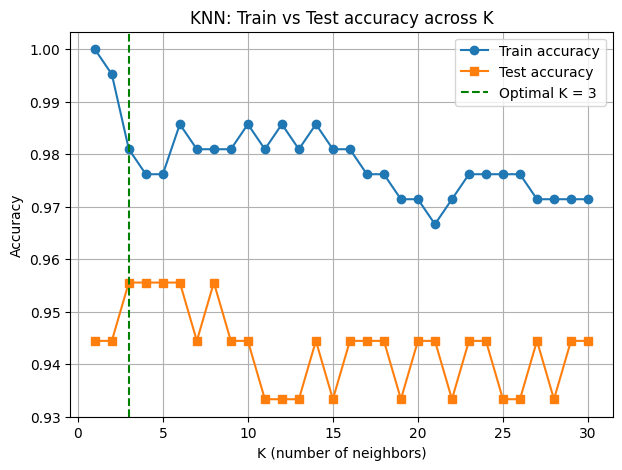

In [7]:
k_range = range(1, 31)
train_accs, test_accs = [], []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_s, y_train)
    train_accs.append(accuracy_score(y_train, knn.predict(X_train_s)))
    test_accs.append(accuracy_score(y_test, knn.predict(X_test_s)))

best_k = list(k_range)[int(np.argmax(test_accs))]
print(f"Optimal K (best test accuracy) = {best_k}  ->  test accuracy = {max(test_accs):.4f}")

plt.plot(k_range, train_accs, marker='o', label='Train accuracy')
plt.plot(k_range, test_accs, marker='s', label='Test accuracy')
plt.axvline(best_k, color='green', linestyle='--', label=f'Optimal K = {best_k}')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN: Train vs Test accuracy across K')
plt.legend()
plt.show()


Final KNN (K=3) test accuracy: 0.9556

              precision    recall  f1-score   support

         Bad       0.96      0.96      0.96        45
        Good       0.96      0.96      0.96        45

    accuracy                           0.96        90
   macro avg       0.96      0.96      0.96        90
weighted avg       0.96      0.96      0.96        90



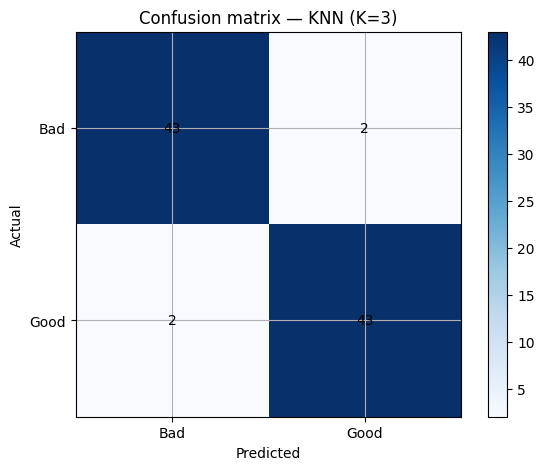

In [8]:
# Rebuild the final model using the optimal K
final_knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
final_knn.fit(X_train_s, y_train)
y_pred = final_knn.predict(X_test_s)

print(f"Final KNN (K={best_k}) test accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Bad', 'Good']))

cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues')
plt.title(f'Confusion matrix — KNN (K={best_k})')
plt.xticks([0, 1], ['Bad', 'Good']); plt.yticks([0, 1], ['Bad', 'Good'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.colorbar()
plt.show()


### 4) Apply for both classification and regression

Classification with KNN is already done above (steps 1–3). Now we apply KNN to a **regression** problem too. KNN regression follows the **same** algorithm, except the last step **averages** the K nearest neighbors' target values instead of voting on a class. We build a fresh 4-parameter regression dataset (`House_Size`, `Rooms`, `Age`, `Distance_to_City` → `Price`) to demonstrate this.


In [9]:
Xr, yr = make_regression(n_samples=300, n_features=4, n_informative=4, noise=12, random_state=42)
reg_feature_names = ['House_Size', 'Rooms', 'Age', 'Distance_to_City']
df_reg = pd.DataFrame(Xr, columns=reg_feature_names)
df_reg = (df_reg - df_reg.min()) / (df_reg.max() - df_reg.min())
df_reg['House_Size'] = 500 + df_reg['House_Size'] * 2500       # sq. ft
df_reg['Rooms'] = 1 + (df_reg['Rooms'] * 6).round()             # 1-7 rooms
df_reg['Age'] = (df_reg['Age'] * 40).round()                    # years
df_reg['Distance_to_City'] = (df_reg['Distance_to_City'] * 30).round(1)  # km
df_reg['Price'] = (yr - yr.min()) / (yr.max() - yr.min()) * 900000 + 100000  # $
df_reg['Price'] = df_reg['Price'].round(2)

df_reg.to_csv('regression_dataset.csv', index=False)
df_reg.head()


,House_Size,Rooms,Age,Distance_to_City,Price
0,1418.429067,4.0,12.0,23.0,563822.14
1,1654.890764,3.0,18.0,26.2,607863.57
2,941.987905,3.0,14.0,10.6,209566.89
3,1358.514227,3.0,25.0,16.6,363209.51
4,1749.621088,5.0,11.0,20.4,711122.05


Optimal K for regression (best test R^2) = 6  ->  test R^2 = 0.8649, RMSE = 57611.22


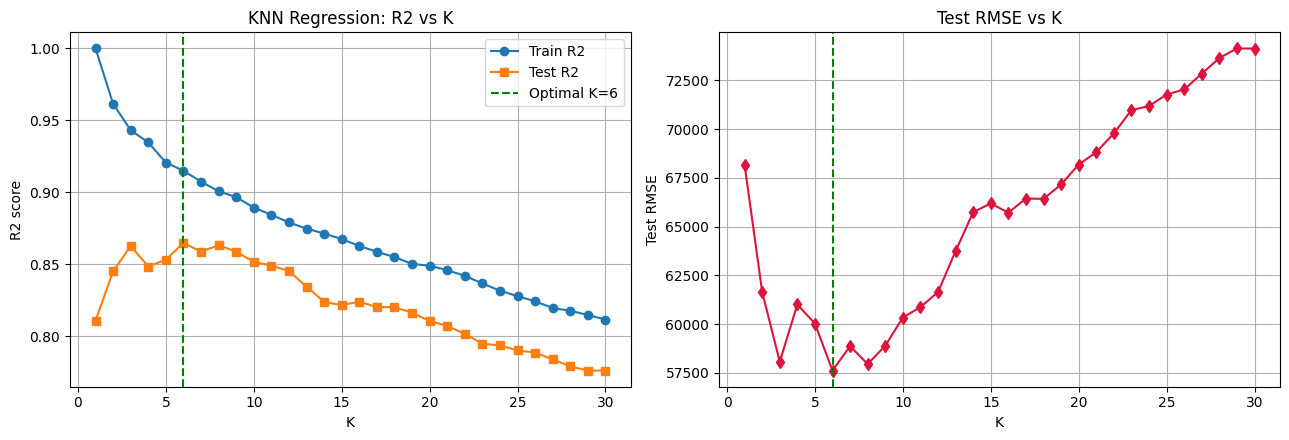

In [10]:
Xr = df_reg[reg_feature_names].values
yr_target = df_reg['Price'].values

Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr_target, test_size=0.3, random_state=42)
r_scaler = StandardScaler().fit(Xr_train)
Xr_train_s = r_scaler.transform(Xr_train)
Xr_test_s = r_scaler.transform(Xr_test)

k_range_r = range(1, 31)
train_r2, test_r2, test_rmse = [], [], []

for k in k_range_r:
    knr = KNeighborsRegressor(n_neighbors=k)
    knr.fit(Xr_train_s, yr_train)
    train_r2.append(r2_score(yr_train, knr.predict(Xr_train_s)))
    pred = knr.predict(Xr_test_s)
    test_r2.append(r2_score(yr_test, pred))
    test_rmse.append(np.sqrt(mean_squared_error(yr_test, pred)))

best_k_r = list(k_range_r)[int(np.argmax(test_r2))]
print(f"Optimal K for regression (best test R^2) = {best_k_r}  ->  test R^2 = {max(test_r2):.4f}, "
      f"RMSE = {test_rmse[int(np.argmax(test_r2))]:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(k_range_r, train_r2, marker='o', label='Train R2')
ax[0].plot(k_range_r, test_r2, marker='s', label='Test R2')
ax[0].axvline(best_k_r, color='green', linestyle='--', label=f'Optimal K={best_k_r}')
ax[0].set_xlabel('K'); ax[0].set_ylabel('R2 score'); ax[0].legend(); ax[0].set_title('KNN Regression: R2 vs K')

ax[1].plot(k_range_r, test_rmse, marker='d', color='crimson')
ax[1].axvline(best_k_r, color='green', linestyle='--')
ax[1].set_xlabel('K'); ax[1].set_ylabel('Test RMSE'); ax[1].set_title('Test RMSE vs K')
plt.tight_layout(); plt.show()


Final KNN Regressor (K=6)
Test R2  : 0.8649
Test RMSE: 57611.22


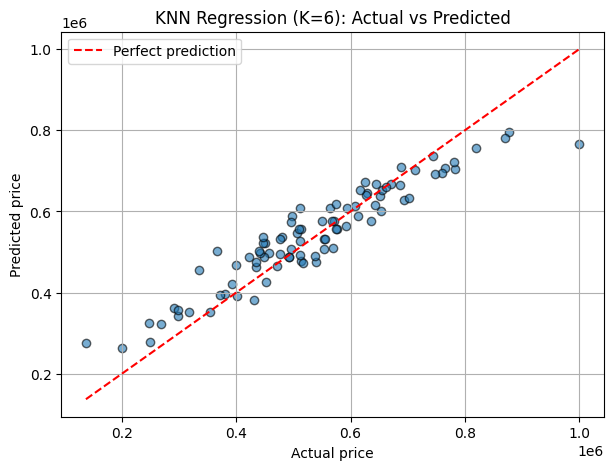

In [11]:
# Rebuild final regressor with optimal K
final_knr = KNeighborsRegressor(n_neighbors=best_k_r)
final_knr.fit(Xr_train_s, yr_train)
pred_final = final_knr.predict(Xr_test_s)

print(f"Final KNN Regressor (K={best_k_r})")
print(f"Test R2  : {r2_score(yr_test, pred_final):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(yr_test, pred_final)):.2f}")

plt.scatter(yr_test, pred_final, alpha=0.6, edgecolor='k')
lims = [min(yr_test.min(), pred_final.min()), max(yr_test.max(), pred_final.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel('Actual price'); plt.ylabel('Predicted price')
plt.title(f'KNN Regression (K={best_k_r}): Actual vs Predicted')
plt.legend(); plt.show()


### 5) Naive Bayes Classification

For comparison against KNN, we also train a Gaussian Naive Bayes classifier on the same classification dataset from step 1.


In [12]:
nb_model = GaussianNB()
nb_model.fit(X_train_s, y_train)
y_pred_nb = nb_model.predict(X_test_s)
nb_acc = accuracy_score(y_test, y_pred_nb)

print(f"Naive Bayes test accuracy: {nb_acc:.4f}\n")
print(classification_report(y_test, y_pred_nb, target_names=['Bad', 'Good']))

comparison = pd.DataFrame({
    'Model': [f'KNN (K={best_k})', 'Gaussian Naive Bayes'],
    'Test accuracy': [accuracy_score(y_test, y_pred), nb_acc]
})
comparison


Naive Bayes test accuracy: 0.9444

              precision    recall  f1-score   support

         Bad       0.98      0.91      0.94        45
        Good       0.92      0.98      0.95        45

    accuracy                           0.94        90
   macro avg       0.95      0.94      0.94        90
weighted avg       0.95      0.94      0.94        90



,Model,Test accuracy
0,KNN (K=3),0.955556
1,Gaussian Naive Bayes,0.944444


---
# 2. K-Means / K-Medoid / K-Means++ Clustering

### Recap from the notes
- **Clustering** partitions a dataset into groups (clusters) that share a common trait, based on a distance measure.
- **K-Means:** repeatedly (1) assign each point to its nearest **centroid** (mean of the cluster), (2) recompute centroids, until no point changes cluster.
- **K-Medoid (PAM):** like K-Means, but the cluster "center" is always an **actual data point** (the medoid) — the object whose *average dissimilarity to every other point in the cluster is minimal*. This makes it **more robust to noise/outliers** than K-Means.
  - **Build step:** sequentially select `k` "centrally located" objects as the initial medoids.
  - **Swap step:** for every (selected, non-selected) pair, compute the swap cost; if the total cost decreases, swap; repeat until the cost can no longer be reduced.


## a) Perform K-Means for a sample data points using Euclidean / Manhattan / Squared Euclidean / Cosine distance measures

### a.0 — A small worked example first (manual, matching the handwritten notes)

Before running the full pipeline on a larger dataset, here is a small, fully worked K-Means example with `K=3`, mirroring the style of the notes.


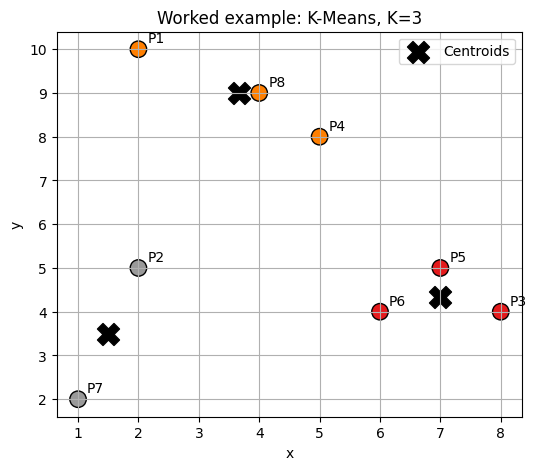

Final centroids:
 [[7.   4.33]
 [3.67 9.  ]
 [1.5  3.5 ]]


In [13]:
demo_points = np.array([
    [2, 10], [2, 5], [8, 4], [5, 8], [7, 5], [6, 4], [1, 2], [4, 9]
])
demo_labels = [f'P{i+1}' for i in range(len(demo_points))]

demo_km = KMeans(n_clusters=3, init='random', n_init=10, random_state=42).fit(demo_points)

plt.figure(figsize=(6, 5))
plt.scatter(demo_points[:, 0], demo_points[:, 1], c=demo_km.labels_, cmap='Set1', s=140, edgecolor='k')
for i, txt in enumerate(demo_labels):
    plt.annotate(txt, (demo_points[i, 0] + 0.15, demo_points[i, 1] + 0.15))
plt.scatter(demo_km.cluster_centers_[:, 0], demo_km.cluster_centers_[:, 1],
            marker='X', s=250, c='black', label='Centroids')
plt.title('Worked example: K-Means, K=3')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.show()

print("Final centroids:\n", demo_km.cluster_centers_.round(2))


### a.1 — Generate the sample data points (main clustering dataset)

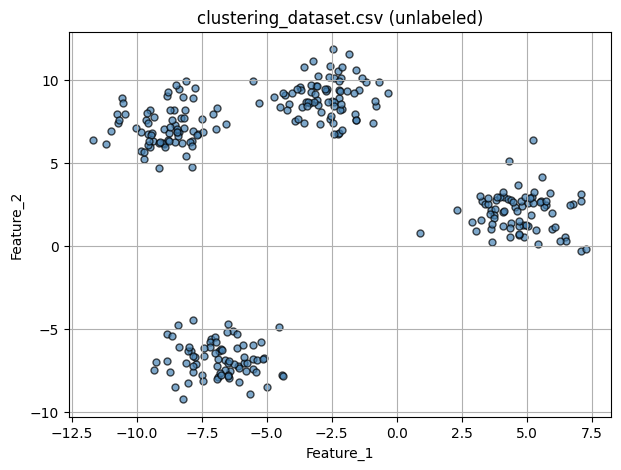

,Feature_1,Feature_2
0,-9.366593,6.346202
1,-9.827803,6.881284
2,-1.563271,7.610316
3,-7.129961,-5.616516
4,-11.182171,6.164224


In [14]:
Xc, yc_true = make_blobs(n_samples=300, centers=4, n_features=2, cluster_std=1.15, random_state=42)
df_cluster = pd.DataFrame(Xc, columns=['Feature_1', 'Feature_2'])
df_cluster.to_csv('clustering_dataset.csv', index=False)

plt.scatter(df_cluster['Feature_1'], df_cluster['Feature_2'], s=25, c='steelblue', edgecolor='k', alpha=0.7)
plt.title('clustering_dataset.csv (unlabeled)')
plt.xlabel('Feature_1'); plt.ylabel('Feature_2'); plt.show()
df_cluster.head()


### a.2 — K-Means from scratch, with the 4 distance measures

- **Euclidean distance measure** — straight-line distance
- **Manhattan distance measure** — sum of absolute differences (taxicab / city-block)
- **Squared Euclidean distance measure** — Euclidean distance without the square root (what K-Means actually minimizes internally)
- **Cosine distance measure** — 1 − cosine similarity; measures the *angle* between vectors, ignoring magnitude

For Euclidean / Manhattan / Squared-Euclidean the centroid update is the arithmetic mean. For Cosine distance the centroid is the mean vector re-normalized to unit length (the natural cluster "direction").


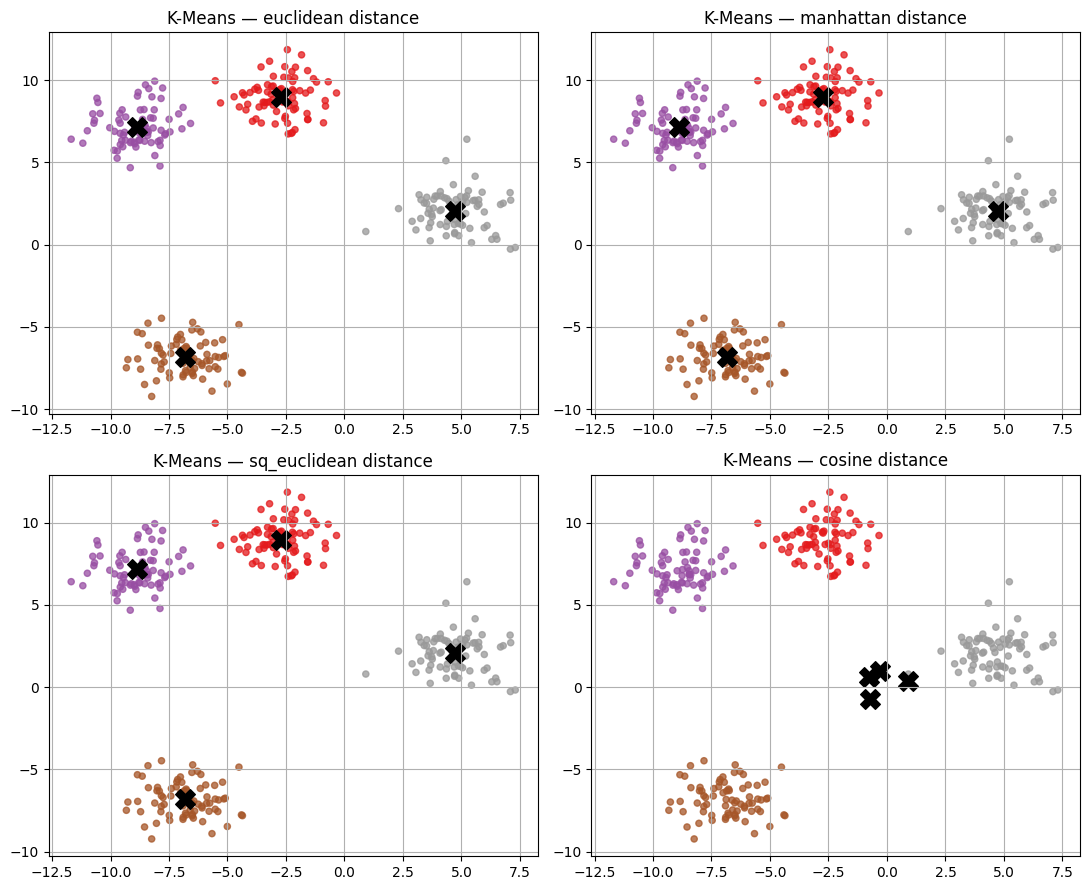

In [15]:
def pairwise_distance(X, centers, metric):
    if metric in ('euclidean', 'sq_euclidean'):
        d = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
        return d if metric == 'sq_euclidean' else np.sqrt(d)
    elif metric == 'manhattan':
        return np.abs(X[:, None, :] - centers[None, :, :]).sum(axis=2)
    elif metric == 'cosine':
        Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
        Cn = centers / (np.linalg.norm(centers, axis=1, keepdims=True) + 1e-12)
        return 1 - Xn @ Cn.T
    else:
        raise ValueError(metric)


def kmeans_scratch(X, k, metric='euclidean', n_iter=100, random_state=42, init_centers=None):
    rng = np.random.default_rng(random_state)
    X = np.asarray(X, dtype=float)
    centers = X[rng.choice(len(X), k, replace=False)].copy() if init_centers is None else init_centers.copy()

    for _ in range(n_iter):
        dist = pairwise_distance(X, centers, metric)
        labels = dist.argmin(axis=1)
        new_centers = centers.copy()
        for j in range(k):
            members = X[labels == j]
            if len(members) == 0:
                continue
            if metric == 'cosine':
                m = members.mean(axis=0)
                new_centers[j] = m / (np.linalg.norm(m) + 1e-12)
            else:
                new_centers[j] = members.mean(axis=0)
        if np.allclose(new_centers, centers):
            break
        centers = new_centers

    return labels, centers


metrics = ['euclidean', 'manhattan', 'sq_euclidean', 'cosine']
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
Xc_arr = df_cluster.values

for ax, metric in zip(axes.ravel(), metrics):
    labels, centers = kmeans_scratch(Xc_arr, k=4, metric=metric, random_state=42)
    ax.scatter(Xc_arr[:, 0], Xc_arr[:, 1], c=labels, cmap='Set1', s=20, alpha=0.75)
    ax.scatter(centers[:, 0], centers[:, 1], marker='X', s=200, c='black')
    ax.set_title(f'K-Means — {metric} distance')

plt.tight_layout(); plt.show()


## b) K-Means++ initialization

Random initialization can pick two initial centroids close together, leading to poor / unstable clusters. **K-Means++** instead picks each new centroid with probability proportional to its **squared distance** from the nearest centroid already chosen — spreading the initial centroids out. We compare it against plain random initialization below.


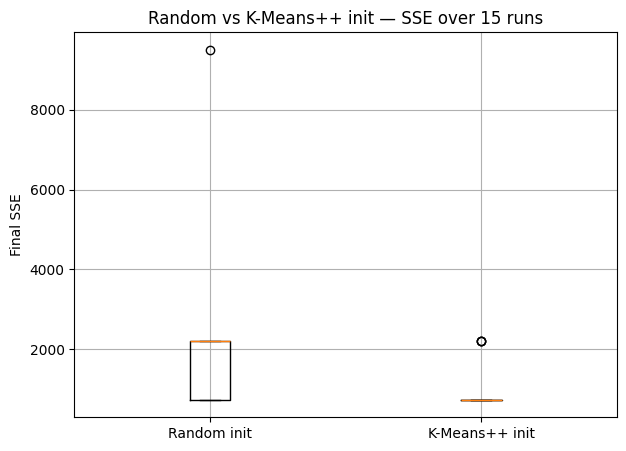

Mean SSE — random init   : 2013.31  (std 2123.07)
Mean SSE — k-means++ init: 1035.97  (std 589.76)

K-Means++ typically reaches a lower AND more consistent (lower std) SSE across runs.


In [16]:
def kmeans_plusplus_init(X, k, random_state=42):
    rng = np.random.default_rng(random_state)
    X = np.asarray(X, dtype=float)
    centers = [X[rng.integers(len(X))]]
    for _ in range(1, k):
        d2 = np.min([((X - c) ** 2).sum(axis=1) for c in centers], axis=0)
        probs = d2 / d2.sum()
        next_center = X[rng.choice(len(X), p=probs)]
        centers.append(next_center)
    return np.array(centers)


def sse(X, labels, centers):
    return sum(((X[labels == j] - centers[j]) ** 2).sum() for j in range(len(centers)))


n_runs = 15
random_sse, plusplus_sse = [], []
for seed in range(n_runs):
    rng = np.random.default_rng(seed)
    rand_init = Xc_arr[rng.choice(len(Xc_arr), 4, replace=False)]
    lbl_r, cen_r = kmeans_scratch(Xc_arr, 4, metric='euclidean', random_state=seed, init_centers=rand_init)
    random_sse.append(sse(Xc_arr, lbl_r, cen_r))

    pp_init = kmeans_plusplus_init(Xc_arr, 4, random_state=seed)
    lbl_pp, cen_pp = kmeans_scratch(Xc_arr, 4, metric='euclidean', random_state=seed, init_centers=pp_init)
    plusplus_sse.append(sse(Xc_arr, lbl_pp, cen_pp))

plt.boxplot([random_sse, plusplus_sse], tick_labels=['Random init', 'K-Means++ init'])
plt.ylabel('Final SSE'); plt.title(f'Random vs K-Means++ init — SSE over {n_runs} runs')
plt.show()

print(f"Mean SSE — random init   : {np.mean(random_sse):.2f}  (std {np.std(random_sse):.2f})")
print(f"Mean SSE — k-means++ init: {np.mean(plusplus_sse):.2f}  (std {np.std(plusplus_sse):.2f})")
print("\nK-Means++ typically reaches a lower AND more consistent (lower std) SSE across runs.")


## c) K-Medoid (PAM) clustering: Build step + Swap step, from scratch

This follows the algorithm exactly as written in the notes:
1. Select `k` random points from the data as medoids.
2. Associate each point to its closest medoid (by distance).
3. For each pair of a non-selected object `h` and a selected object `i`, compute the total swapping cost `TC_ih`. If `TC_ih < 0`, replace `i` with `h`.
4. Repeat steps 2–3 until there is no change of medoid.

Because the swap step is `O(k · n²)` per iteration, we demonstrate it on a smaller sample (40 points) for speed.


iter 0: cost=52.886
iter 1: cost=52.886

Final total cost: 52.886
Medoid points:
[[ 4.62  2.11]
 [-3.44  8.44]
 [-6.4  -7.53]
 [-8.41  6.63]]


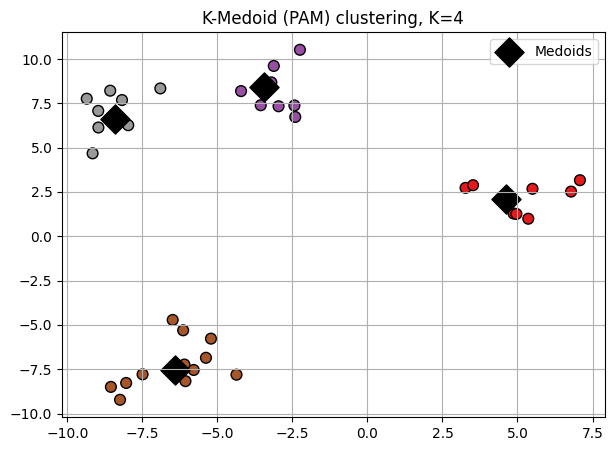

In [17]:
def k_medoids_pam(X, k, random_state=42, max_iter=100, verbose=False):
    rng = np.random.default_rng(random_state)
    X = np.asarray(X, dtype=float)
    n = len(X)
    D = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(axis=2))  # full distance matrix

    medoid_idx = list(rng.choice(n, k, replace=False))  # Build step (simplified: random start)

    def total_cost(medoids):
        return D[:, medoids].min(axis=1).sum()

    current_cost = total_cost(medoid_idx)
    for iteration in range(max_iter):
        improved = False
        for i_pos, i in enumerate(medoid_idx):
            for h in range(n):
                if h in medoid_idx:
                    continue
                trial = medoid_idx.copy()
                trial[i_pos] = h
                new_cost = total_cost(trial)
                if new_cost < current_cost:
                    medoid_idx, current_cost, improved = trial, new_cost, True
        if verbose:
            print(f"iter {iteration}: cost={current_cost:.3f}")
        if not improved:
            break

    labels = D[:, medoid_idx].argmin(axis=1)
    return np.array(medoid_idx), labels, current_cost


sample_idx = np.random.default_rng(1).choice(len(Xc_arr), 40, replace=False)
X_small = Xc_arr[sample_idx]

medoid_idx, pam_labels, pam_cost = k_medoids_pam(X_small, k=4, random_state=42, verbose=True)
print(f"\nFinal total cost: {pam_cost:.3f}")
print(f"Medoid points:\n{X_small[medoid_idx].round(2)}")

plt.scatter(X_small[:, 0], X_small[:, 1], c=pam_labels, cmap='Set1', s=60, edgecolor='k')
plt.scatter(X_small[medoid_idx, 0], X_small[medoid_idx, 1], marker='D', s=220, c='black', label='Medoids')
plt.title('K-Medoid (PAM) clustering, K=4'); plt.legend(); plt.show()


### c.1 — Why K-Medoid is more robust to noise (outlier demo)

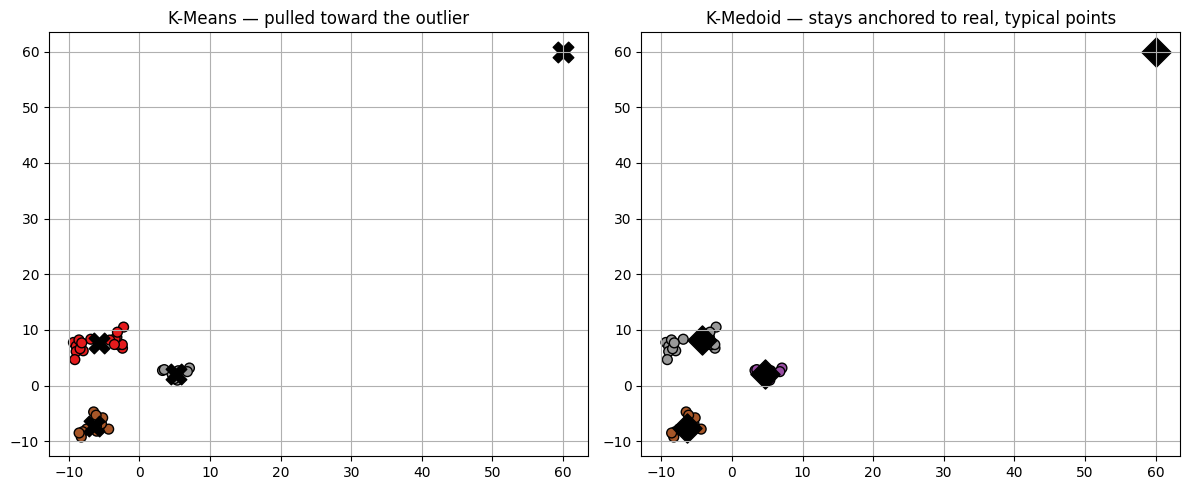

In [18]:
X_outlier = np.vstack([X_small, [[60, 60]]])  # inject one extreme outlier

# K-Means (mean-based) is dragged toward the outlier
km_out = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_outlier)

# K-Medoid ignores it, since a medoid must be an actual (typical) data point
med_idx_out, pam_labels_out, _ = k_medoids_pam(X_outlier, k=4, random_state=42)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(X_outlier[:, 0], X_outlier[:, 1], c=km_out.labels_, cmap='Set1', s=50, edgecolor='k')
ax[0].scatter(km_out.cluster_centers_[:, 0], km_out.cluster_centers_[:, 1], marker='X', s=220, c='black')
ax[0].set_title('K-Means — pulled toward the outlier')

ax[1].scatter(X_outlier[:, 0], X_outlier[:, 1], c=pam_labels_out, cmap='Set1', s=50, edgecolor='k')
ax[1].scatter(X_outlier[med_idx_out, 0], X_outlier[med_idx_out, 1], marker='D', s=220, c='black')
ax[1].set_title('K-Medoid — stays anchored to real, typical points')
plt.tight_layout(); plt.show()


## d) Apply K-Means for applications

### d) i) Image Compression

Each pixel is a point in 3D RGB space. Running K-Means with `K` colors and replacing every pixel with its cluster's centroid color compresses the image's color palette to just `K` colors — a classic K-Means use case (vector quantization).


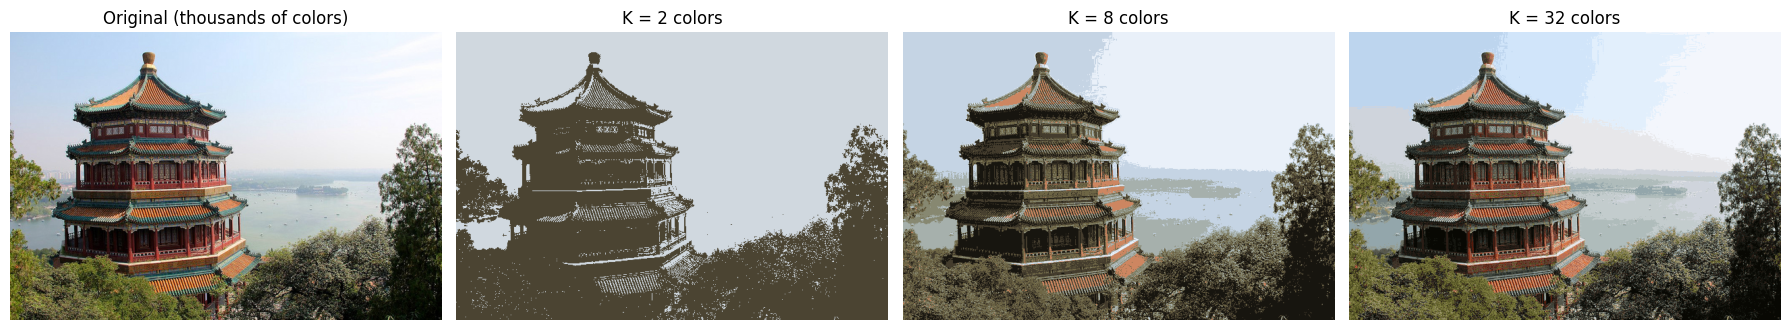

Original image size (colors): up to 96615 unique colors


In [19]:
china = load_sample_image('china.jpg')          # built into scikit-learn, works offline
china = china / 255.0                             # scale to [0,1]
w, h, d = china.shape
pixels = china.reshape(-1, d)

# use a subsample to fit K-Means quickly, then predict on the full image
rng = np.random.default_rng(42)
sample = pixels[rng.choice(len(pixels), 2000, replace=False)]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(china); axes[0].set_title('Original (thousands of colors)'); axes[0].axis('off')

for ax, k in zip(axes[1:], [2, 8, 32]):
    km_img = KMeans(n_clusters=k, n_init=4, random_state=42).fit(sample)
    labels_full = km_img.predict(pixels)
    compressed = km_img.cluster_centers_[labels_full].reshape(w, h, d)
    ax.imshow(compressed); ax.set_title(f'K = {k} colors'); ax.axis('off')

plt.tight_layout(); plt.show()
print("Original image size (colors): up to", len(np.unique(pixels.reshape(-1, 3), axis=0)), "unique colors")


### d) ii) Identify players that are similar to each other

We generate a synthetic basketball stats dataset (`Points`, `Assists`, `Rebounds`, `Steals` per game for 40 players), then use K-Means to group players into playing-style clusters — e.g. "scorers", "playmakers", "rebounders" — and find which players are most similar to a chosen reference player.


In [20]:
rng = np.random.default_rng(7)
n_players = 40
# 3 latent play-styles, each with its own stat profile + noise
styles = rng.integers(0, 3, n_players)
base = np.array([
    [24, 3, 5, 1.0],   # scorers: high points
    [8, 9, 4, 1.8],    # playmakers: high assists/steals
    [10, 2, 11, 0.7],  # rebounders: high rebounds
])
stats = base[styles] + rng.normal(0, 1.3, size=(n_players, 4))
stats = np.clip(stats, 0.2, None).round(1)

players_df = pd.DataFrame(stats, columns=['Points', 'Assists', 'Rebounds', 'Steals'])
players_df.insert(0, 'Player', [f'Player_{i+1}' for i in range(n_players)])
players_df.to_csv('player_stats_dataset.csv', index=False)

p_scaler = StandardScaler()
players_scaled = p_scaler.fit_transform(players_df[['Points', 'Assists', 'Rebounds', 'Steals']])

km_players = KMeans(n_clusters=3, n_init=10, random_state=42).fit(players_scaled)
players_df['Cluster'] = km_players.labels_
players_df.head(10)


,Player,Points,Assists,Rebounds,Steals,Cluster
0,Player_1,7.6,1.7,9.4,1.1,1
1,Player_2,8.2,8.8,0.7,1.1,0
2,Player_3,9.9,2.1,9.0,0.2,1
3,Player_4,8.7,0.9,12.4,0.2,1
4,Player_5,8.0,10.1,3.2,1.7,0
5,Player_6,10.1,2.1,9.4,0.8,1
6,Player_7,11.8,0.2,12.1,0.9,1
7,Player_8,23.2,5.6,6.0,0.2,2
8,Player_9,24.1,3.7,4.8,1.9,2
9,Player_10,23.9,3.9,6.9,0.2,2


Players in the same cluster (playing style) as Player_1:
   Player  Points  Assists  Rebounds  Steals
 Player_1     7.6      1.7       9.4     1.1
 Player_3     9.9      2.1       9.0     0.2
 Player_4     8.7      0.9      12.4     0.2
 Player_6    10.1      2.1       9.4     0.8
 Player_7    11.8      0.2      12.1     0.9
Player_12     9.2      1.7      12.2     2.2
Player_13     8.3      1.0      11.8     0.2
Player_16     9.4      1.6      11.5     0.5
Player_18    11.5      2.8      11.0     1.6
Player_21     9.6      0.8      11.2     3.6
Player_25    10.3      0.9      12.3     1.0
Player_27     8.5      2.5       8.2     1.8
Player_34     9.3      2.0      10.5     0.3
Player_35     8.2      1.0      13.2     0.2
Player_36     8.6      2.4      12.8     0.2
Player_37     9.7      1.2       8.7     1.7
Player_40    11.7      1.3      11.4     0.7


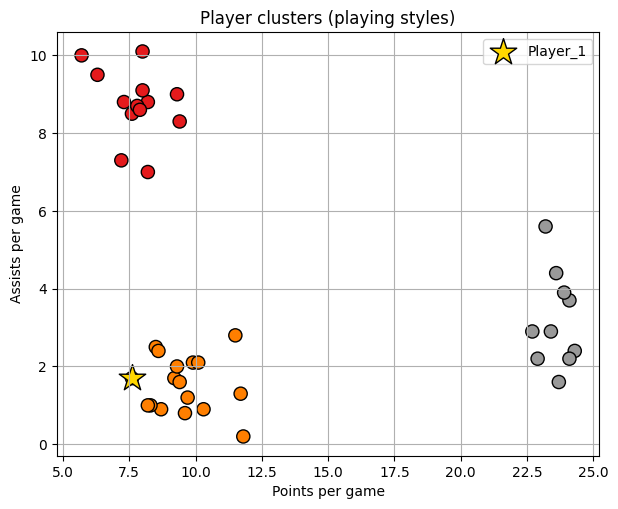

In [21]:
reference_player = 'Player_1'
ref_cluster = players_df.loc[players_df['Player'] == reference_player, 'Cluster'].values[0]
similar = players_df[players_df['Cluster'] == ref_cluster]

print(f"Players in the same cluster (playing style) as {reference_player}:")
print(similar[['Player', 'Points', 'Assists', 'Rebounds', 'Steals']].to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5.5))
scatter = ax.scatter(players_df['Points'], players_df['Assists'],
                      c=players_df['Cluster'], cmap='Set1', s=90, edgecolor='k')
ax.scatter(players_df.loc[players_df.Player == reference_player, 'Points'],
           players_df.loc[players_df.Player == reference_player, 'Assists'],
           marker='*', s=400, c='gold', edgecolor='black', label=reference_player)
ax.set_xlabel('Points per game'); ax.set_ylabel('Assists per game')
ax.set_title('Player clusters (playing styles)'); ax.legend(); plt.show()


## e) Evaluate the method using

### e) i) Silhouette Coefficient &nbsp; ii) Sum of Squared Errors

- **Sum of Squared Errors (SSE / WCSS)** — sum of squared distances from each point to its assigned centroid. Lower is tighter clusters, but SSE always decreases as `K` increases (down to 0 at `K = n`), so it alone can't pick the *best* `K`.
- **Silhouette Coefficient** (range −1 to 1) — for each point, compares its average distance to points in its own cluster vs. the nearest other cluster. Higher is better; values near 1 mean well-separated clusters.


In [22]:
k_values = range(2, 11)
sse_scores, silhouette_scores = [], []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xc_arr)
    sse_scores.append(km.inertia_)                              # SSE / WCSS
    silhouette_scores.append(silhouette_score(Xc_arr, km.labels_))

eval_df = pd.DataFrame({'K': list(k_values), 'SSE (WCSS)': sse_scores, 'Silhouette': silhouette_scores})
eval_df


,K,SSE (WCSS),Silhouette
0,2,9599.897555,0.580476
1,3,2283.504984,0.740678
2,4,741.084705,0.761831
3,5,671.739687,0.640650
4,6,604.375632,0.514301
5,7,539.409413,0.424446
6,8,477.448986,0.337559
7,9,429.219389,0.351222
8,10,380.562481,0.363926


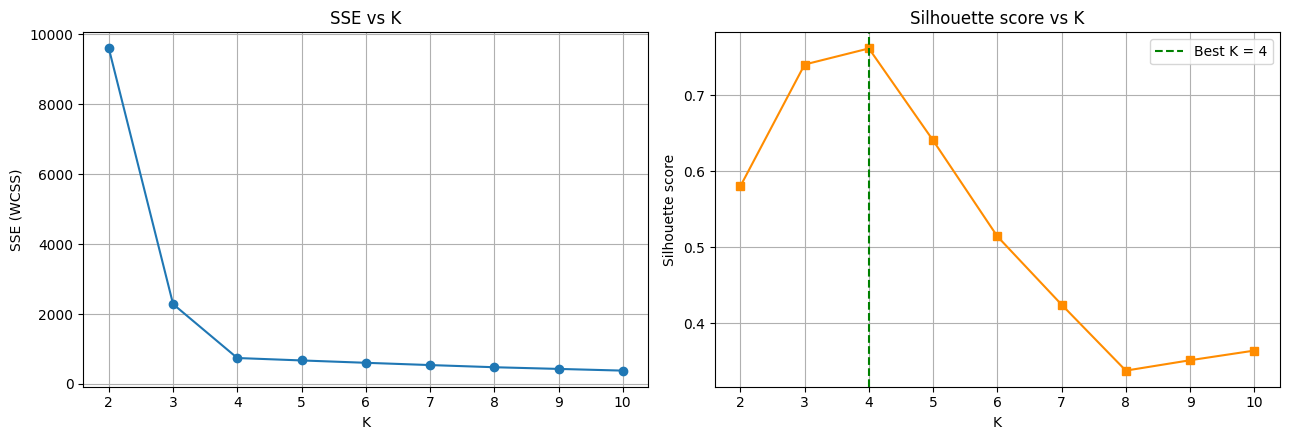

Best K by silhouette score: 4 (score = 0.7618)


In [23]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(k_values, sse_scores, marker='o')
ax[0].set_xlabel('K'); ax[0].set_ylabel('SSE (WCSS)'); ax[0].set_title('SSE vs K')

ax[1].plot(k_values, silhouette_scores, marker='s', color='darkorange')
best_k_sil = list(k_values)[int(np.argmax(silhouette_scores))]
ax[1].axvline(best_k_sil, color='green', linestyle='--', label=f'Best K = {best_k_sil}')
ax[1].set_xlabel('K'); ax[1].set_ylabel('Silhouette score'); ax[1].set_title('Silhouette score vs K'); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"Best K by silhouette score: {best_k_sil} (score = {max(silhouette_scores):.4f})")


## f) Find the optimal K number of clusters using the elbow method

The **elbow method** plots WCSS (SSE) against `K` and looks for the "elbow" — the point where adding another cluster stops giving a big drop in SSE. We locate it programmatically as the point of maximum curvature (distance from the line joining the first and last points).


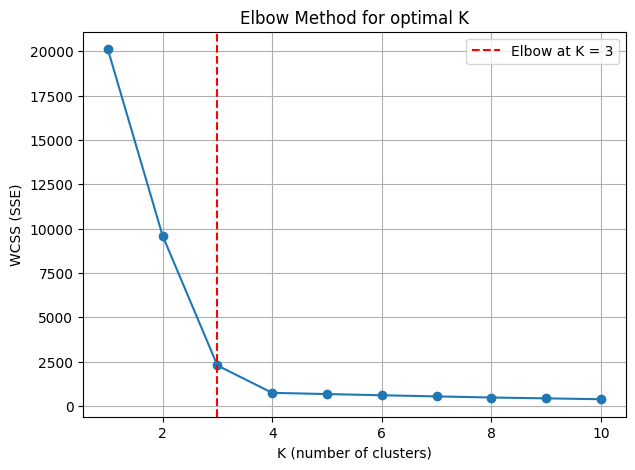

Elbow method suggests optimal K = 3
(The dataset was generated with make_blobs(centers=4) — so K=4 is the 'ground truth'.)


In [24]:
k_elbow_range = list(range(1, 11))
wcss = []
for k in k_elbow_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xc_arr)
    wcss.append(km.inertia_)

# Programmatic elbow detection: max perpendicular distance from the chord (first-last point line)
points = np.array(list(zip(k_elbow_range, wcss)), dtype=float)
line_vec = points[-1] - points[0]
line_vec_norm = line_vec / np.linalg.norm(line_vec)
vec_from_first = points - points[0]
proj = (vec_from_first @ line_vec_norm)[:, None] * line_vec_norm
perp = vec_from_first - proj
distances = np.linalg.norm(perp, axis=1)
elbow_k = k_elbow_range[int(np.argmax(distances))]

plt.plot(k_elbow_range, wcss, marker='o')
plt.axvline(elbow_k, color='red', linestyle='--', label=f'Elbow at K = {elbow_k}')
plt.xlabel('K (number of clusters)'); plt.ylabel('WCSS (SSE)')
plt.title('Elbow Method for optimal K'); plt.legend(); plt.show()

print(f"Elbow method suggests optimal K = {elbow_k}")
print(f"(The dataset was generated with make_blobs(centers=4) — so K=4 is the 'ground truth'.)")


---
# Summary

| Step | Outcome |
|---|---|
| 1.1) KNN distances (a,b,c) | Euclidean / Manhattan / Minkowski implemented & compared |
| 1.2) Train & test accuracy | tabulated per distance metric |
| 1.3) Optimal K + rebuild | printed above |
| 1.4) KNN classification & regression | both done above |
| 1.5) Naive Bayes | compared against KNN above |
| 2.a) K-Means — 4 distance measures | visualized above |
| 2.b) K-Means++ vs random init | K-Means++ → lower & more stable SSE |
| 2.c) K-Medoid (PAM) | more robust to outliers than K-Means |
| 2.d.i) Image compression | K colors via K-Means centroids |
| 2.d.ii) Similar players | grouped by playing style |
| 2.e) Silhouette + SSE | printed above |
| 2.f) Elbow method — best K | printed above |

### Files generated by this notebook
- `classification_dataset.csv` — 4-feature KNN/Naive-Bayes classification data
- `regression_dataset.csv` — 4-feature KNN regression data
- `clustering_dataset.csv` — 2D clustering data (K-Means/K-Means++/K-Medoid)
- `player_stats_dataset.csv` — player-similarity clustering data
